# Dataset audit — keep or leave

One section per registered dataset; the verdict lives in the markdown cell that closes each section (notebook-only for now).

The composition these verdicts feed is **SPEC d32**: 50K total — 60% span-evidence rows (80% against span-type targets / 20% no-preference), 20% statistical strata, 20% dark forest (feature-blind draws from ≥3 generalist champions, ≤50% each).

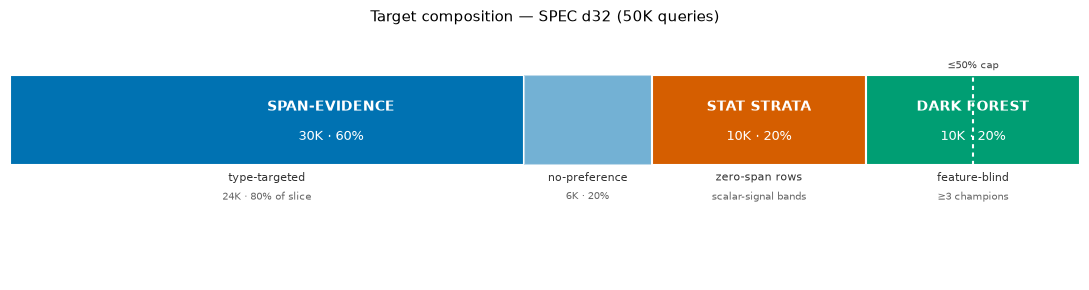

In [3]:
from report_charts import target_composition

target = target_composition()

Evidence per dataset:

- **Identifier profile** — span mass by domain (donut inner ring); the outer ring splits *certified* formats vs hatched *shape-guesses*. A dataset kept **for** its identifiers should be kept on certified spans, not guesses. The companion bar is prevalence ("% of queries touching the domain"), not mass.
- **Coverage dominance** — the cells of the SPEC d31 coverage grids (x band × spans per query) where this dataset is the *equal-weight dominant* source. Size is debiased: a 100-query set can out-weigh msmarco in a cell.

Rubric:

- **Narrow ≠ leave.** A specialist that owns a rare stratum stays, however small.
- **Redundancy = leave.** Dominating no cell *and* adding no identifier flavor others lack is the drop signal.
- **Caveat:** dominance is winner-take-all — a strong runner-up everywhere scores 0 (this is exactly msmarco's situation). Check volume/qrels/eval value before dropping a backbone.

Draft verdicts were auto-derived (≥2 cells → KEEP, 1 → LEAN KEEP, 0 → REVIEW) and hand-annotated — **edit the verdict cells to record final decisions.**

In [12]:
# Evidence assembly — all inputs are local artifacts (data/profiles/*.json,
# data/feature_table/catalog.parquet); no network.
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from dataset_registry import DATASETS
from query_taxonomy.features import CorpusFeatures
from query_taxonomy.reporting import CorpusReport
from query_taxonomy.banks import BANKS
from query_taxonomy.taxonomy import FeatureGroup
from report_charts import (
    DEFAULT_AXES,
    CoverageMap,
    coverage_map_grid,
    domain_share_bar,
    feature_donut,
)

PROFILES = Path("data/profiles")


class DatasetAudit:
    """Keep/leave evidence for the registered datasets: identifier profile
    (what kinds, certified vs shape-guesses) plus coverage dominance (which
    cells of the SPEC d31 grids each dataset uniquely characterizes)."""

    def __init__(self, catalog: pd.DataFrame) -> None:
        self.catalog = catalog
        self.maps = {x.title: CoverageMap(catalog, x) for x in DEFAULT_AXES}
        self.datasets = {d.name: d for d in DATASETS}
        self.reports = {
            name: CorpusReport(CorpusFeatures.model_validate_json(
                (PROFILES / f"{name}.json").read_text()
            ))
            for name in self.datasets
        }

    def dominated_cells(self, name: str) -> list[tuple[str, str, str]]:
        """(axis, x band, span bucket) cells where `name` is the equal-weight
        dominant source. Winner-take-all: a strong #2 everywhere scores 0."""
        cells = []
        for title, map_ in self.maps.items():
            dominant = map_.dominant
            for row in dominant.index:
                for col in dominant.columns:
                    if dominant.loc[row, col] == name:
                        cells.append(
                            (title, str(col).replace("\n", " "), str(row))
                        )
        return cells

    def identifier_evidence(self, name: str) -> dict[str, object]:
        slices = self.reports[name].domain_rollup()
        spans = sum(s.spans for s in slices)
        certified = sum(s.certified for s in slices)
        return {
            "id_spans": spans,
            "certified_share": certified / spans if spans else 0.0,
            "top_domains": ", ".join(
                f"{s.label} ({s.spans})" for s in slices[:3]
            ),
        }

    def summary(self) -> pd.DataFrame:
        catalog_rows = self.catalog["dataset"].value_counts()
        rows = []
        for name, dataset in self.datasets.items():
            evidence = self.identifier_evidence(name)
            rows.append({
                "dataset": name,
                "grounding": dataset.card.grounding.value,
                "queries": dataset.queries_cached,
                "catalog_rows": int(catalog_rows[name]),
                "id_spans": evidence["id_spans"],
                "certified": f"{evidence['certified_share']:.0%}",
                "top_domains": evidence["top_domains"],
                "cells_dominated": len(self.dominated_cells(name)),
            })
        return pd.DataFrame(rows).sort_values(
            "cells_dominated", ascending=False, ignore_index=True
        )

    def show(self, name: str) -> None:
        dataset, report = self.datasets[name], self.reports[name]
        card, evidence = dataset.card, self.identifier_evidence(name)
        print(
            f"grounding={card.grounding.value}  source={card.source.value}  "
            f"availability={card.availability.value}  "
            f"queries={dataset.queries_cached:,}"
        )
        print(
            f"identifiers: {evidence['id_spans']:,} spans, "
            f"{evidence['certified_share']:.0%} certified — "
            f"top: {evidence['top_domains'] or 'none'}"
        )
        cells = self.dominated_cells(name)
        print(f"dominates {len(cells)} coverage cells:")
        for axis, band, bucket in cells:
            print(f"  {axis}: {band} x {bucket}")
        feature_donut(report, title=f"{name} — feature spans").tight_layout()
        plt.show()
        domain_share_bar(
            report, title=f"{name} — domain query share"
        ).tight_layout()
        plt.show()

    def _targets(self) -> dict[str, list[str]]:
        """Floor targets -> catalog columns. Identifier domains count
        CERTIFIED banks only (*_like shape-guesses excluded); marker and
        logical types are deterministic closed lists, one target each."""
        domain_of = {
            bank_type().name.value: bank_type().domain.value
            for bank_type in BANKS
        }
        targets: dict[str, list[str]] = {}
        for column in self.catalog.columns:
            group, _, type_ = column.partition(".")
            if group == FeatureGroup.STRUCTURED_IDENTIFIERS.value:
                if type_.endswith("_like"):
                    # wrong about the domain, right about identifier-ness
                    # (SciFact self-audit): shape-guesses pool into one
                    # domain-agnostic column instead of polluting floors
                    key = "id:shape_guess"
                    targets.setdefault(key, []).append(column)
                    continue
                domain = domain_of[type_]
                # general = number + datetime: number would drown any
                # aggregate it joins, so general banks get own columns
                key = f"id:{type_}" if domain == "general" else f"id:{domain}"
            elif group == FeatureGroup.SENTENCE_MARKERS.value:
                key = f"marker:{type_}"
            elif group == FeatureGroup.LOGICAL_STRUCTURES.value:
                key = f"logical:{type_}"
            else:
                continue
            targets.setdefault(key, []).append(column)
        return {
            key: targets[key]
            for prefix in ("id:", "marker:", "logical:")
            for key in sorted(targets)
            if key.startswith(prefix)
        }

    def _supply(self, reduce) -> pd.DataFrame:
        columns = {
            target: reduce(self.catalog[cols])
            .groupby(self.catalog["dataset"])
            .sum()
            for target, cols in self._targets().items()
        }
        frame = (
            pd.DataFrame(columns)
            .reindex(list(self.datasets))
            .fillna(0)
            .astype(int)
        )
        catalog_rows = self.catalog["dataset"].value_counts()
        frame.insert(0, "scale", [
            f"x{(self.datasets[name].queries_cached or int(catalog_rows[name])) / int(catalog_rows[name]):.0f}"
            for name in frame.index
        ])
        return frame

    def floor_supply(self) -> pd.DataFrame:
        """Queries carrying >=1 qualifying span per target — floors are
        set in queries, so this is the planning table."""
        return self._supply(lambda block: block.gt(0).any(axis=1).astype(int))

    def span_mass(self) -> pd.DataFrame:
        """Raw span counts per target — the density view; one span-dense
        query can carry dozens, so mass != supply."""
        return self._supply(lambda block: block.sum(axis=1))


In [13]:
catalog = pd.read_parquet("data/feature_table/catalog.parquet")
audit = DatasetAudit(catalog)

## The coverage terrain — read this first

The four grids below (SPEC d31; cell text = row count + equal-weight dominant source) are the terrain every verdict plays out on:

- **The catalog is bottom-heavy.** ~86% of rows carry zero feature spans — generalist mass, owned proportionally by `limit`, `orcas`, `crumb-legal-qa`, and even 500-query `trec-dl-2022` (it out-weighs everyone in the modal web-query cell: depth 2-3 × 0 spans, 108K rows). The 50K composition cannot mirror the catalog; quotas bind in the upper rows.
- **Short + evidence-dense is the scarce commodity.** (0-2 words × 3+ spans) holds exactly **1** query; (3-6 × 3+) 111; (flat syntax × 3+) 19; (telegram NL × 3+) 148. A 50K even split implies ~700 rows per cell — any cell below that is take-everything territory, and the shortfall is the generation lane's order sheet.
- **Specialist ownership concentrates at the top.** The 3+ span rows belong almost exclusively to `bright-*` / `rarb-*` / `crumb-*` sets — single-source strata: lose the dataset, lose the cell.
- **Length correlates with evidence but is not required for it** — the 3-6 word column already reaches 3+ spans; short+dense exists, it is just rare.

Verdicts below should be read against this terrain: a dataset that looks boring here can still be a span-type champion (certified tech/network/datetime supply) or an unknown-universe champion (feature-blind generalist mass) — see the rubric above.

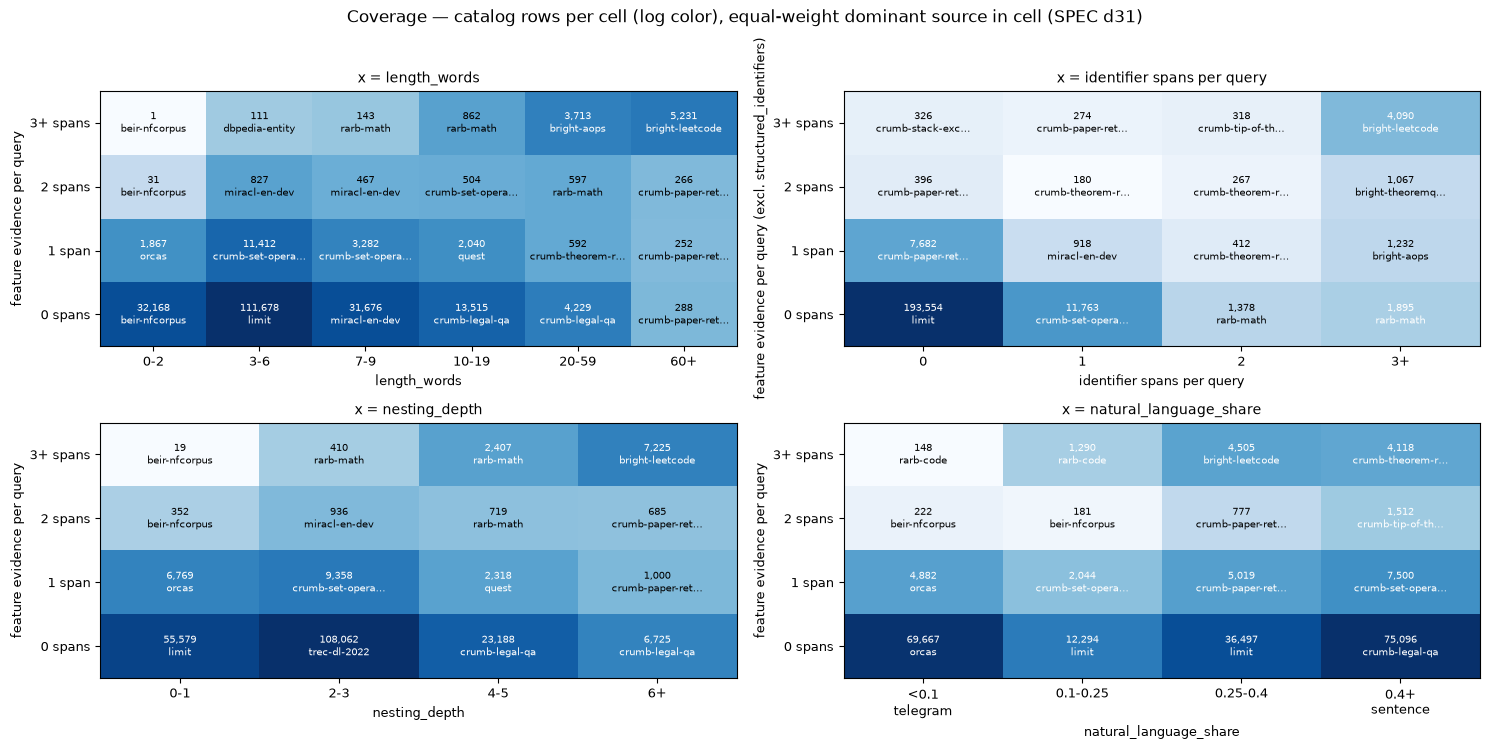

In [14]:
coverage_map_grid(catalog)
plt.show()

In [15]:
audit.summary()

,dataset,grounding,queries,catalog_rows,id_spans,certified,top_domains,cells_dominated
0,crumb-paper-retrieval,query_qrels,72,72,33,6%,"finance (31), number (2)",10
1,rarb-math,query_qrels,6319,6319,43950,90%,"number (31907), finance (7745), tech (4241)",8
2,beir-nfcorpus,query_qrels,323,323,20,25%,"finance (12), tech (4), number (3)",7
3,crumb-set-operation-entity-retrieval,query_qrels,423,423,178,91%,"number (162), finance (16)",7
4,limit,query_qrels,1000,1000,4,50%,"finance (2), number (2)",5
5,miracl-en-dev,query_qrels,799,799,98,26%,"finance (74), number (20), network (2)",5
6,crumb-theorem-retrieval,query_qrels,69,69,249,100%,"number (191), tech (50), finance (5)",5
7,crumb-legal-qa,query_qrels,6753,6753,0,0%,,5
8,orcas,query_corpus,10405342,100000,10495,100%,"number (5786), network (2933), tech (1605)",4
9,bright-leetcode,query_qrels,142,142,7368,99%,"number (6795), tech (445), finance (120)",4


### Sampling caveat — how wrong can a sampled catalog slice be?

Only `orcas` enters the catalog sampled (uniform random 100K of its 10.4M cached queries; every other dataset is in full — compare `catalog_rows` vs `queries`). Two bounds quantify the error:

- **Whole-distribution (DKW inequality):** P(any share in the empirical distribution is off by more than ε) ≤ 2·exp(−2nε²). Evaluated below: at ±0.5pp the risk is ~1.3%, at ±1pp it is ~4×10⁻⁷%. The sample shows the real distribution up to about half a percentage point, with near-certainty.
- **Rare categories (Poisson):** an observed count k scales to ≈ scale·k ± 2·scale·√k in the full cache. 310 observed datetime queries → ~32K ± 3.7K in full orcas (tight); 2 observed → ~200 ± 300 (order of magnitude only). **Treat single-digit observed counts as hints, not supply.**

**So to summarize: "P(any share off by >0.5pp) ≤ 1.3%" reads: there's at most a 1.3% chance that any share in the sample differs from the true share by more than half a percentage point in absolute terms.**


In [16]:
import math


def dkw_risk(n: int, eps_pp: float) -> float:
    """P(any share of the empirical distribution off by > eps_pp points)."""
    eps = eps_pp / 100.0
    return min(1.0, 2.0 * math.exp(-2.0 * n * eps * eps))


catalog_rows = catalog["dataset"].value_counts()
for name, dataset in audit.datasets.items():
    n, cached = int(catalog_rows[name]), dataset.queries_cached
    if cached is None or n >= cached:
        continue  # dataset is in the catalog in full — no sampling error
    scale = cached / n
    print(f"{name}: {n:,} catalog rows of {cached:,} cached (x{scale:.0f})")
    for eps in (0.3, 0.5, 0.7, 1.0):
        print(f"  P(any share off by >{eps}pp) <= {dkw_risk(n, eps):.6%}")
    print(
        f"  rare-count rule: observed k -> full = {scale:.0f}*k +- "
        f"{2 * scale:.0f}*sqrt(k)   "
        f"(k=310 -> {310 * scale:,.0f} +- {2 * scale * math.sqrt(310):,.0f})"
    )

orcas: 100,000 catalog rows of 10,405,342 cached (x104)
  P(any share off by >0.3pp) <= 33.059778%
  P(any share off by >0.5pp) <= 1.347589%
  P(any share off by >0.7pp) <= 0.011090%
  P(any share off by >1.0pp) <= 0.000000%
  rare-count rule: observed k -> full = 104*k +- 208*sqrt(k)   (k=310 -> 32,257 +- 3,664)


### Span-type supply — who can fill each floor?

Two tables, one question each. Domain columns count **certified** banks only; all `*_like` shape-guess banks pool into the domain-agnostic **`id:shape_guess`** column — wrong about the domain, right about identifier-ness (the SciFact self-audit), so they supply sparse-affinity floors but never domain floors. Marker/logical types are deterministic closed lists.

- **Floor supply** — queries carrying ≥1 qualifying span. Floors are set in queries ("≥500 queries with a certified tech span"), so this is the planning table. A column with a single meaningful supplier is a fragility flag — same logic as sole-supplier cells.
- **Span mass** — raw span counts, the density view: one span-dense query can carry dozens (a leetcode query holds 50+ numbers), so mass ≠ supply.

The `general` domain is split into its member banks (`id:number`, `id:datetime`) — number would drown any aggregate it joins. Counts are raw observed rows; `scale` marks sampled datasets (orcas ×104 — see the sampling caveat above; exact supply is harvestable with a ~16-minute regex pass over the full cache whenever a floor demands it).

In [17]:
audit.floor_supply()

,scale,id:datetime,id:finance,id:logistics,id:media,id:medical,id:network,id:number,id:tech,marker:acronym,marker:comparative,marker:greeting,marker:interjection,marker:negation,marker:politeness,logical:code_fragment,logical:math_expression,logical:operator_syntax,logical:temporal
dataset,,,,,,,,,,,,,,,,,,,
msmarco-passage-dev,x1,0,30,34,5,2,63,1503,299,322,1529,39,93,967,933,27,25,0,423
trec-dl-2022,x1,0,0,0,0,0,0,6,0,0,5,0,2,3,6,0,0,0,3
beir-nfcorpus,x1,0,0,0,0,0,1,3,1,14,8,0,0,11,2,0,0,0,0
miracl-en-dev,x1,0,1,1,0,0,2,20,1,81,14,0,0,1,6,0,0,0,4
orcas,x104,0,64,97,6,1,2924,5410,1592,0,1235,49,69,893,133,29,30,0,736
dbpedia-entity,x1,0,0,0,0,0,0,30,0,32,16,0,0,1,0,0,0,0,3
bright-leetcode,x1,0,2,2,1,1,1,142,125,15,67,3,0,94,3,41,99,0,11
bright-aops,x1,0,48,0,0,0,0,97,20,29,17,0,0,21,0,19,63,0,0
bright-theoremqa-questions,x1,0,23,1,0,0,3,144,36,4,29,0,0,38,31,15,20,0,16


In [18]:
audit.span_mass()

,scale,id:datetime,id:finance,id:logistics,id:media,id:medical,id:network,id:number,id:tech,marker:acronym,marker:comparative,marker:greeting,marker:interjection,marker:negation,marker:politeness,logical:code_fragment,logical:math_expression,logical:operator_syntax,logical:temporal
dataset,,,,,,,,,,,,,,,,,,,
msmarco-passage-dev,x1,0,32,35,17,2,63,1671,322,408,1589,39,98,985,936,27,26,0,427
trec-dl-2022,x1,0,0,0,0,0,0,6,0,0,6,0,2,4,6,0,0,0,3
beir-nfcorpus,x1,0,0,0,0,0,1,3,1,15,12,0,0,11,2,0,0,0,0
miracl-en-dev,x1,0,1,1,0,0,2,20,1,88,14,0,0,1,6,0,0,0,4
orcas,x104,0,67,97,6,1,2933,5786,1605,0,1258,51,70,905,134,30,31,0,741
dbpedia-entity,x1,0,0,0,0,0,0,31,0,33,22,0,0,1,0,0,0,0,3
bright-leetcode,x1,0,39,2,2,2,1,6795,445,84,136,13,0,208,5,141,482,0,29
bright-aops,x1,0,123,0,0,0,0,713,79,222,29,0,0,25,0,115,167,0,0
bright-theoremqa-questions,x1,0,36,3,0,0,4,605,116,10,45,0,0,54,31,33,37,0,26


## msmarco-passage-dev

grounding=query_qrels  source=ir_datasets  availability=open  queries=101,093
identifiers: 2,555 spans, 84% certified — top: number (1671), finance (426), tech (329)
dominates 0 coverage cells:


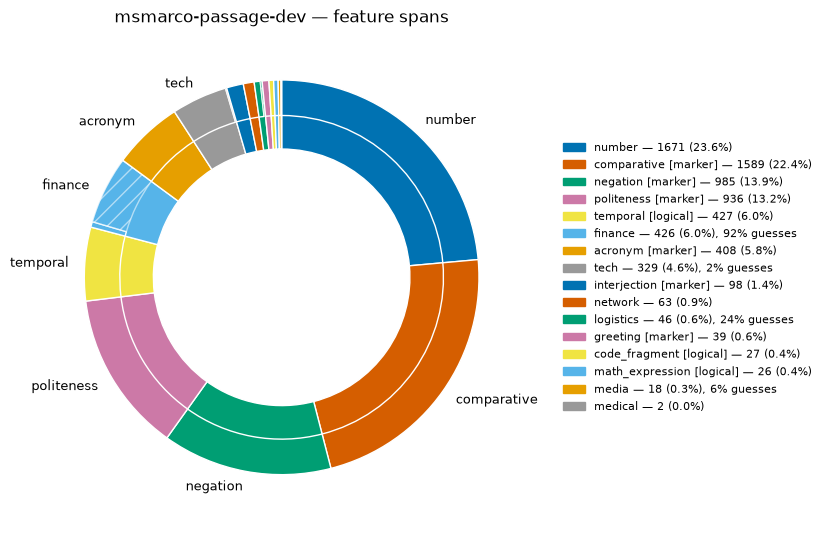

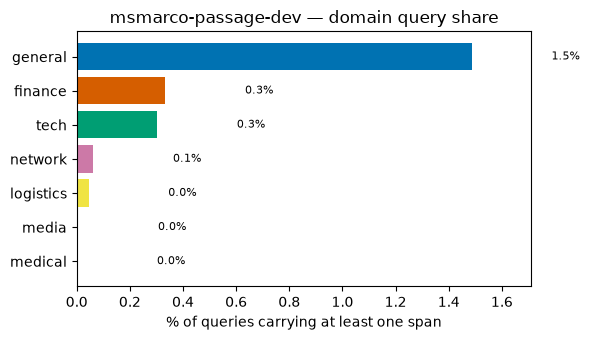

In [19]:
audit.show("msmarco-passage-dev")

**Verdict (draft): REVIEW** — dominates 0 cells — equal weighting strips the 101K-row size advantage and every stratum it covers has a better-fitting specialist. It is the QQ volume backbone though: decide on volume/qrels value, not coverage.

_Edit this cell to record the final decision._

## trec-dl-2022

grounding=query_qrels  source=ir_datasets  availability=open  queries=500
identifiers: 3 spans, 100% certified — top: number (3)
dominates 1 coverage cells:
  nesting_depth: 2-3 x 0 spans


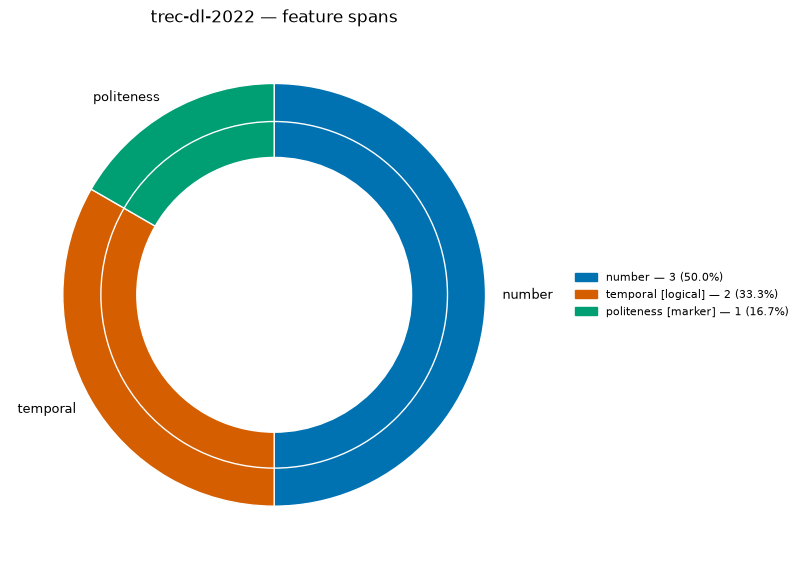

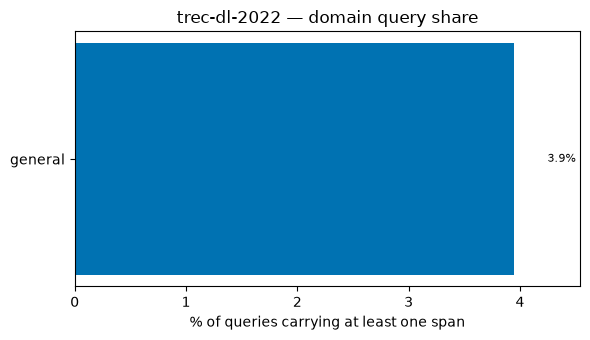

In [20]:
audit.show("trec-dl-2022")

**Verdict (draft): LEAN KEEP** — dominates 1 cell; its real value is eval-side — it is the set the production classifier was measured on (score distribution collapse finding), so it should stay for benchmarking even if it adds little coverage.

_Edit this cell to record the final decision._

## beir-nfcorpus

In [ ]:
audit.show("beir-nfcorpus")

**Verdict (draft): KEEP** — dominates 7 cells — owns the short, evidence-dense telegram strata (0-2 words with 2-3+ spans). Caveat: only 25% of its identifier spans are certified; its identifier profile is mostly shape-guesses.

_Edit this cell to record the final decision._

## miracl-en-dev

grounding=query_qrels  source=huggingface  availability=open  queries=799
identifiers: 98 spans, 26% certified — top: finance (74), number (20), network (2)
dominates 5 coverage cells:
  length_words: 7-9 x 0 spans
  length_words: 3-6 x 2 spans
  length_words: 7-9 x 2 spans
  identifier spans per query: 1 x 1 span
  nesting_depth: 2-3 x 2 spans


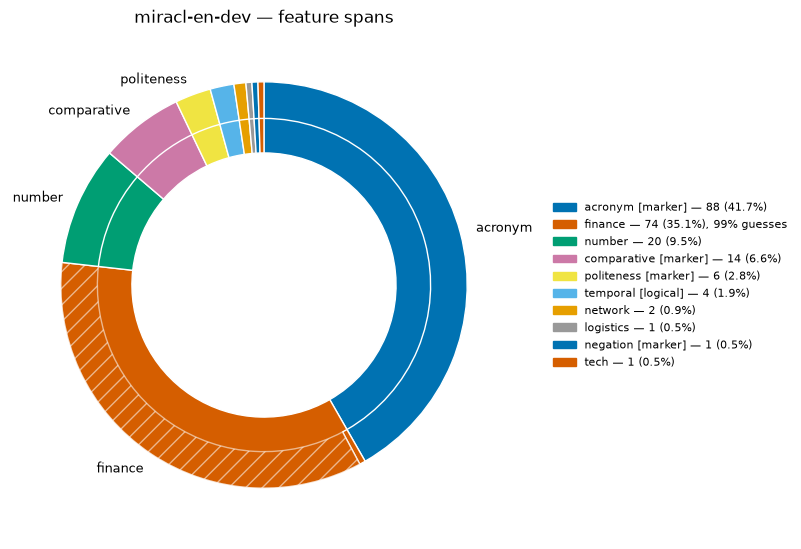

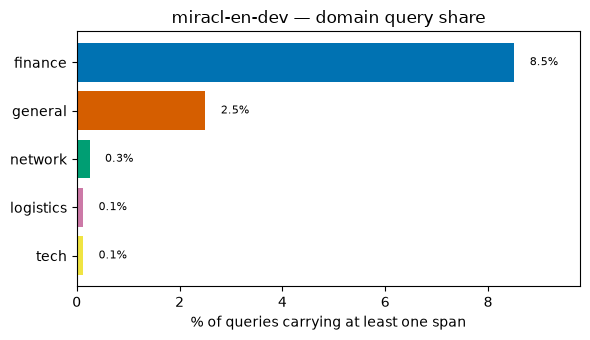

In [21]:
audit.show("miracl-en-dev")

**Verdict (draft): KEEP** — dominates 5 cells — mid-length, low-evidence natural language; the dense-friendly stratum (~3% identifier density, mostly NUMBER).

_Edit this cell to record the final decision._

## orcas

grounding=query_corpus  source=ir_datasets  availability=open  queries=10,405,342
identifiers: 10,495 spans, 100% certified — top: number (5786), network (2933), tech (1605)
dominates 4 coverage cells:
  length_words: 0-2 x 1 span
  nesting_depth: 0-1 x 1 span
  natural_language_share: <0.1 telegram x 0 spans
  natural_language_share: <0.1 telegram x 1 span


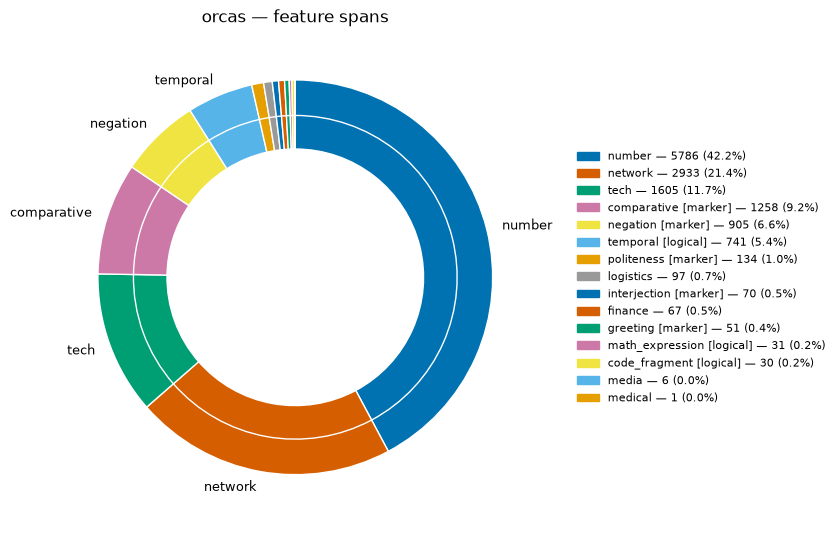

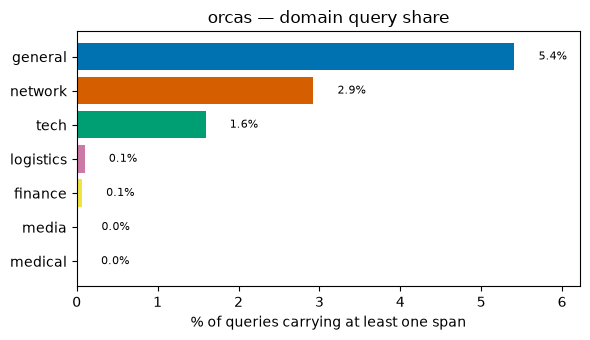

In [22]:
audit.show("orcas")

**Verdict (draft): KEEP** — dominates 4 cells — the web-scale keyword-telegram stratum (natural_language_share < 0.1), 100% certified identifiers.

_Edit this cell to record the final decision._

## dbpedia-entity

grounding=query_qrels  source=ir_datasets  availability=open  queries=400
identifiers: 56 spans, 55% certified — top: number (31), finance (24), logistics (1)
dominates 1 coverage cells:
  length_words: 3-6 x 3+ spans


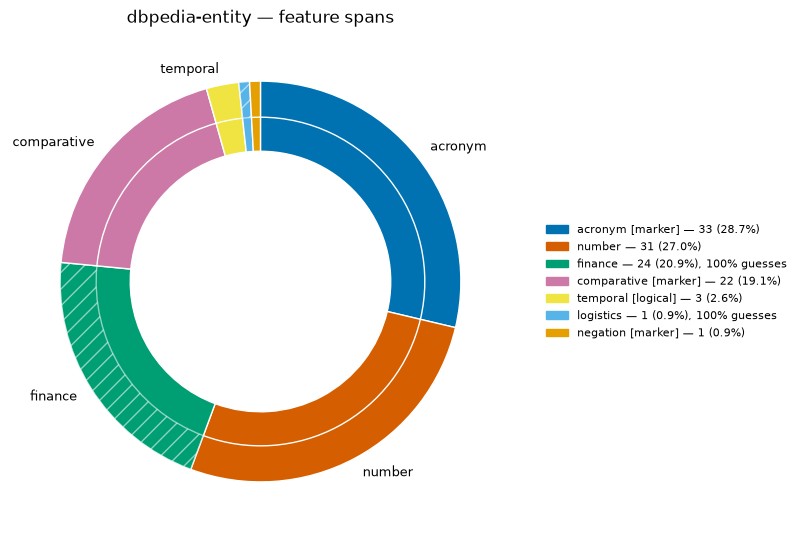

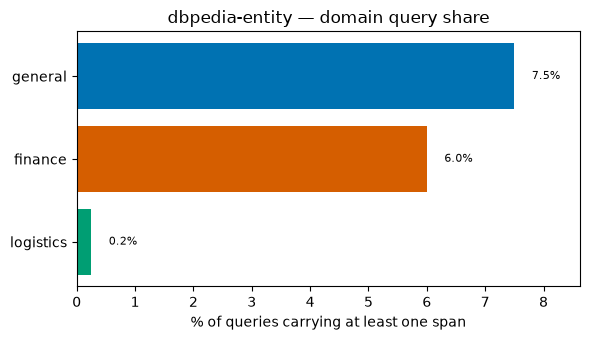

In [23]:
audit.show("dbpedia-entity")

**Verdict (draft): LEAN KEEP** — dominates 1 cell (3-6 words × 3+ spans) — entity-lookup flavor at mid length.

_Edit this cell to record the final decision._

## bright-leetcode

grounding=query_qrels  source=huggingface  availability=open  queries=142
identifiers: 7,368 spans, 99% certified — top: number (6795), tech (445), finance (120)
dominates 4 coverage cells:
  length_words: 60+ x 3+ spans
  identifier spans per query: 3+ x 3+ spans
  nesting_depth: 6+ x 3+ spans
  natural_language_share: 0.25-0.4 x 3+ spans


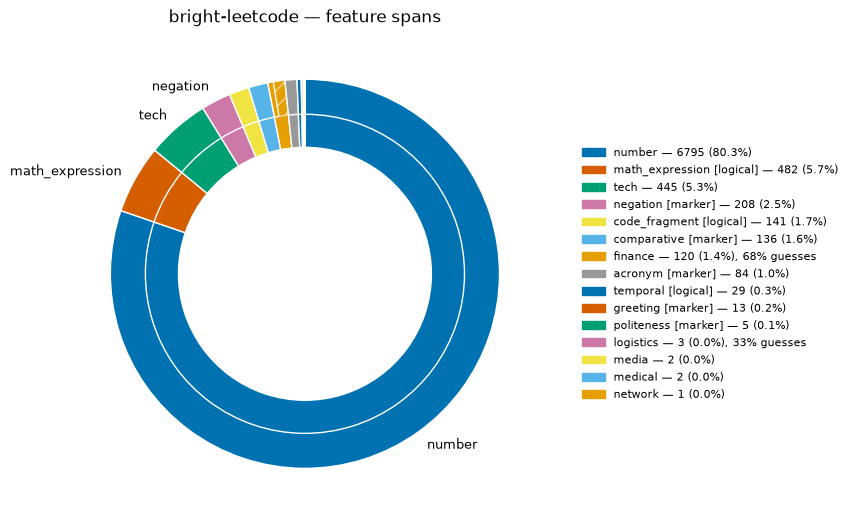

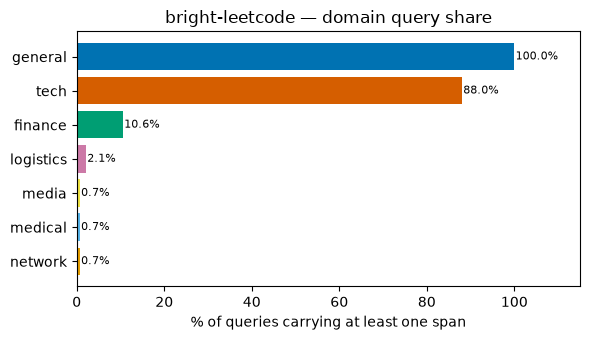

In [24]:
audit.show("bright-leetcode")

**Verdict (draft): KEEP** — dominates 4 cells — the long, identifier-saturated extreme (60+ words × 3+ spans, 3+ ids × 3+ spans), 99% certified.

_Edit this cell to record the final decision._

## bright-aops

grounding=query_qrels  source=huggingface  availability=open  queries=111
identifiers: 1,306 spans, 70% certified — top: number (713), finance (514), tech (79)
dominates 2 coverage cells:
  length_words: 20-59 x 3+ spans
  identifier spans per query: 3+ x 1 span


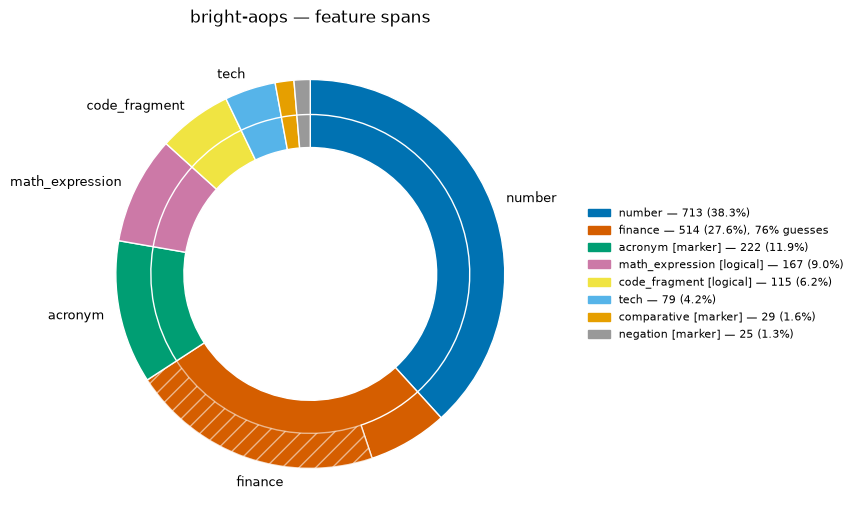

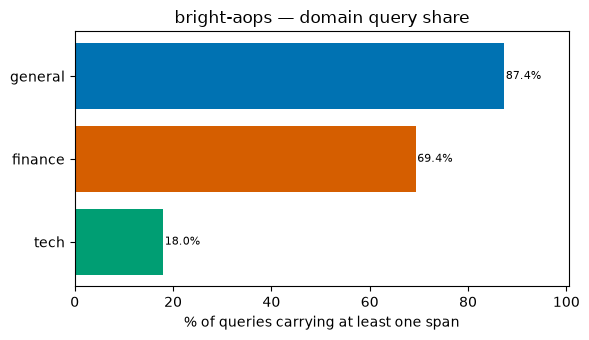

In [25]:
audit.show("bright-aops")

**Verdict (draft): KEEP** — dominates 2 cells — long math statements (20-59 words × 3+ spans).

_Edit this cell to record the final decision._

## bright-theoremqa-questions

grounding=query_qrels  source=huggingface  availability=open  queries=194
identifiers: 776 spans, 98% certified — top: number (605), tech (116), finance (48)
dominates 1 coverage cells:
  identifier spans per query: 3+ x 2 spans


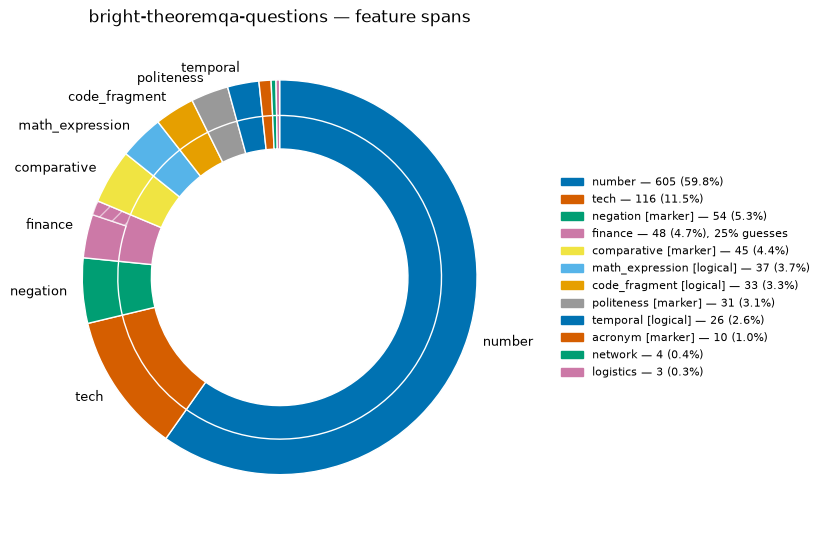

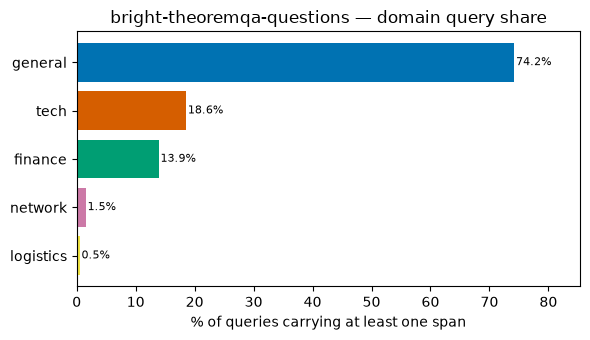

In [26]:
audit.show("bright-theoremqa-questions")

**Verdict (draft): LEAN KEEP** — dominates 1 cell (3+ identifiers × 2 spans); mostly shadowed by rarb-math on neighboring cells.

_Edit this cell to record the final decision._

## quest

grounding=query_qrels  source=huggingface  availability=open  queries=2,050
identifiers: 513 spans, 87% certified — top: number (447), finance (65), tech (1)
dominates 2 coverage cells:
  length_words: 10-19 x 1 span
  nesting_depth: 4-5 x 1 span


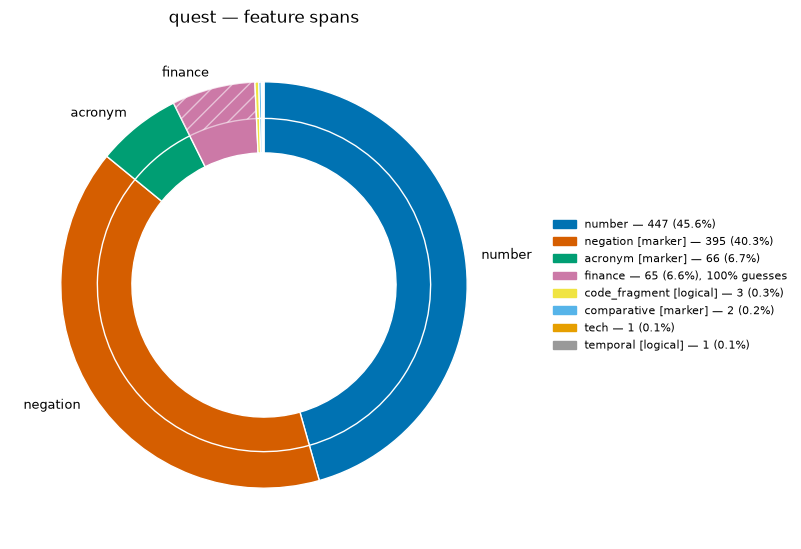

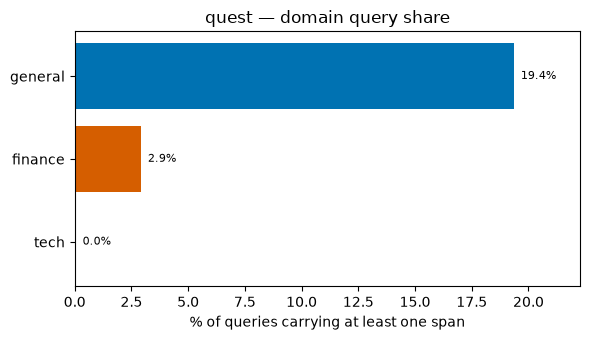

In [27]:
audit.show("quest")

**Verdict (draft): KEEP** — dominates 2 cells — 10-19 word single-span queries, 87% certified.

_Edit this cell to record the final decision._

## crumb-clinical-trial

grounding=query_qrels  source=huggingface  availability=open  queries=113
identifiers: 1,222 spans, 71% certified — top: number (566), finance (350), tech (284)
dominates 0 coverage cells:


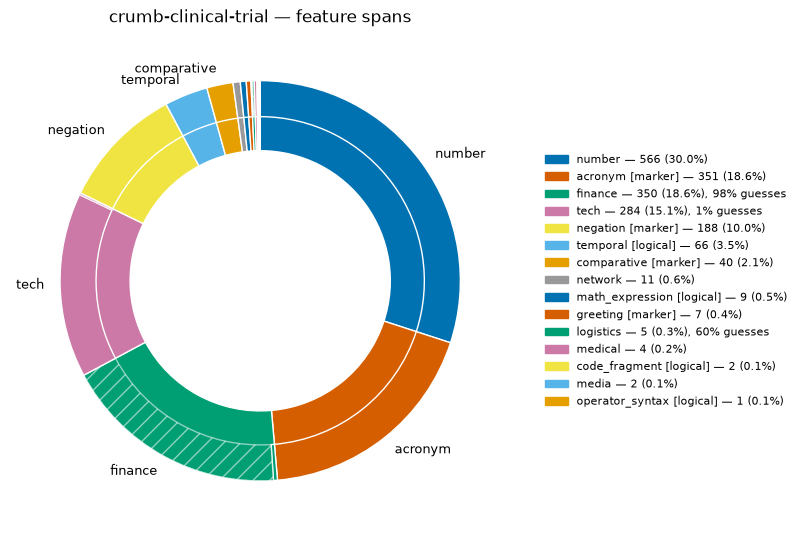

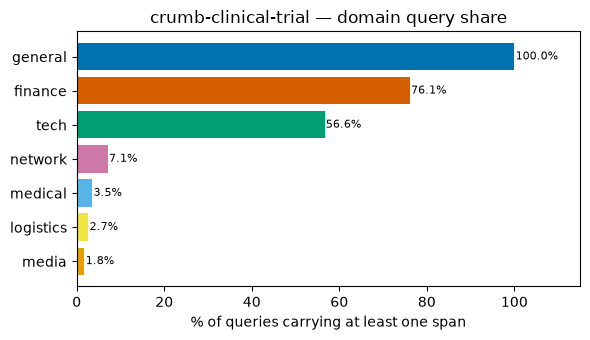

In [28]:
audit.show("crumb-clinical-trial")

**Verdict (draft): REVIEW** — dominates 0 cells and only 113 queries; its identifier mix (number/finance/tech) is duplicated by the code and math sets. Leave candidate unless the clinical domain itself is wanted.

_Edit this cell to record the final decision._

## crumb-code-retrieval

grounding=query_qrels  source=huggingface  availability=open  queries=3,665
identifiers: 33,583 spans, 94% certified — top: number (21147), tech (7337), finance (4925)
dominates 0 coverage cells:


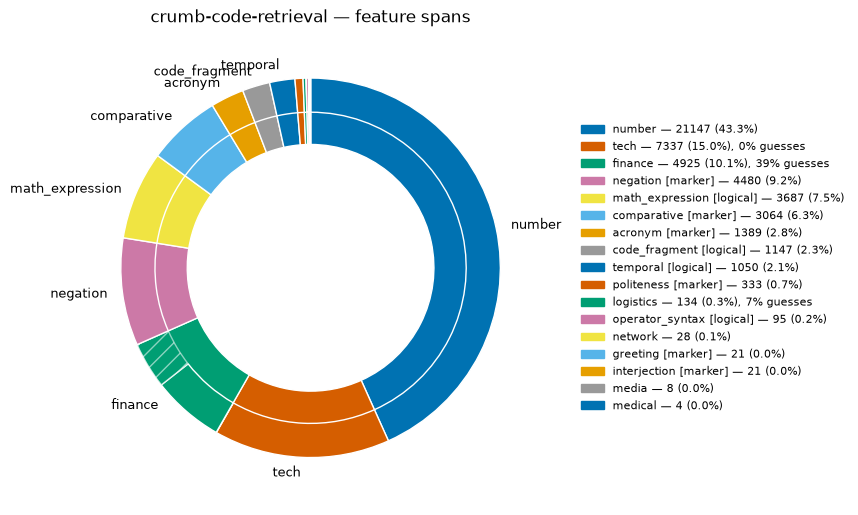

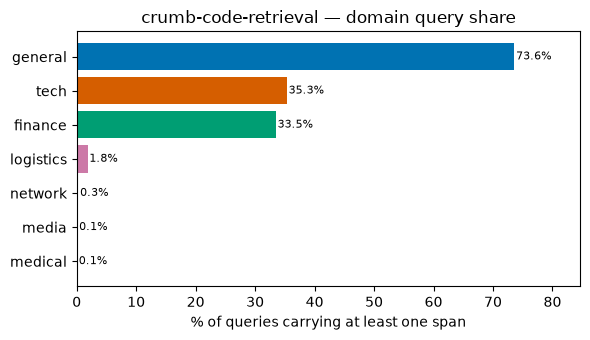

In [29]:
audit.show("crumb-code-retrieval")

**Verdict (draft): REVIEW** — dominates 0 cells despite 33K identifier spans (94% certified) — rarb-code and bright-leetcode own its strata under equal weight. Redundancy candidate: keep only if its 3.6K queries add volume the two owners cannot.

_Edit this cell to record the final decision._

## crumb-legal-qa

grounding=query_qrels  source=huggingface  availability=open  queries=6,753
identifiers: 0 spans, 0% certified — top: none
dominates 5 coverage cells:
  length_words: 10-19 x 0 spans
  length_words: 20-59 x 0 spans
  nesting_depth: 4-5 x 0 spans
  nesting_depth: 6+ x 0 spans
  natural_language_share: 0.4+ sentence x 0 spans


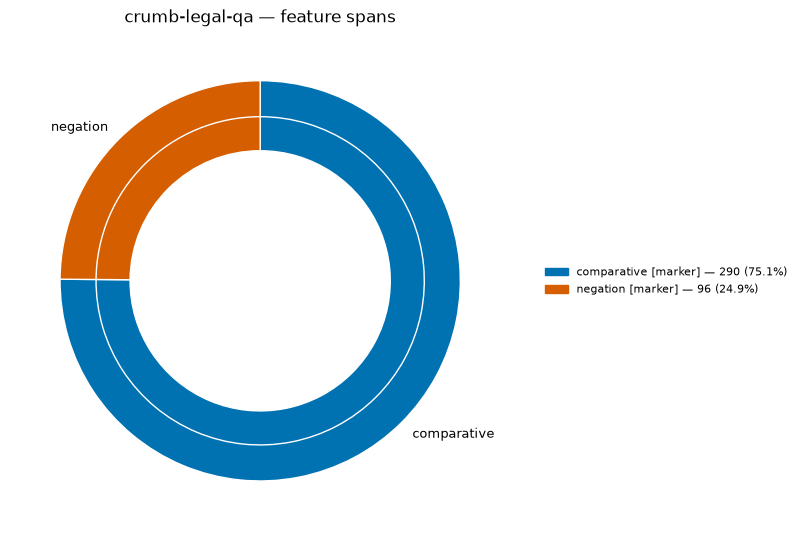

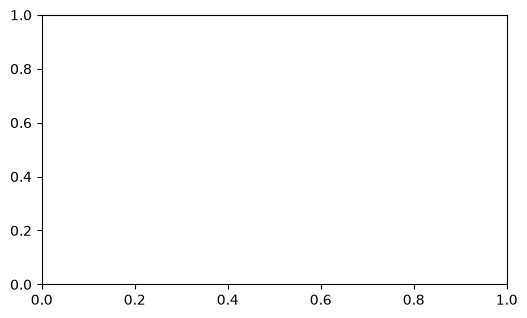

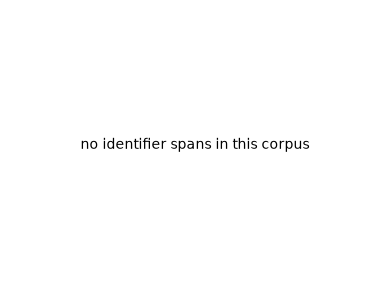

In [30]:
audit.show("crumb-legal-qa")

**Verdict (draft): KEEP** — dominates 5 cells with ZERO identifier spans — owns the long, clean natural-language stratum (10-59 words, 0 spans, 0.4+ NL share). Proof that no identifiers ≠ leave; this is dense-stratum supply.

_Edit this cell to record the final decision._

## crumb-paper-retrieval

grounding=query_qrels  source=huggingface  availability=open  queries=72
identifiers: 33 spans, 6% certified — top: finance (31), number (2)
dominates 10 coverage cells:
  length_words: 60+ x 0 spans
  length_words: 60+ x 1 span
  length_words: 60+ x 2 spans
  identifier spans per query: 0 x 1 span
  identifier spans per query: 0 x 2 spans
  identifier spans per query: 1 x 3+ spans
  nesting_depth: 6+ x 1 span
  nesting_depth: 6+ x 2 spans
  natural_language_share: 0.25-0.4 x 1 span
  natural_language_share: 0.25-0.4 x 2 spans


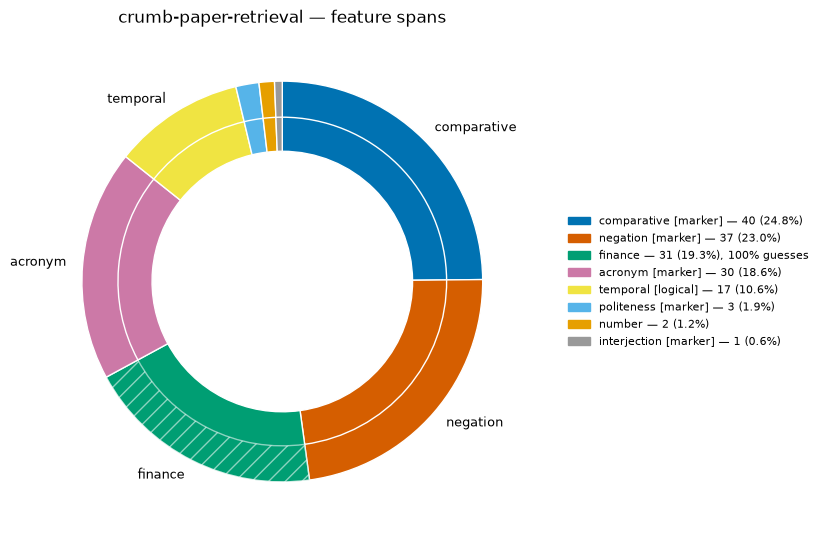

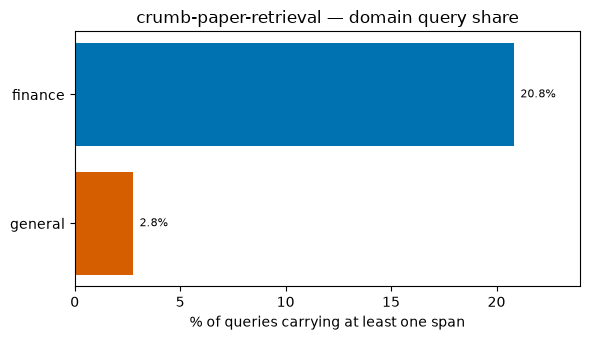

In [31]:
audit.show("crumb-paper-retrieval")

**Verdict (draft): KEEP** — dominates 10 cells from just 72 queries — sole owner of the 60+ word stratum and deep-nesting cells. Highest leverage per query in the registry.

_Edit this cell to record the final decision._

## crumb-set-operation-entity-retrieval

grounding=query_qrels  source=huggingface  availability=open  queries=423
identifiers: 178 spans, 91% certified — top: number (162), finance (16)
dominates 7 coverage cells:
  length_words: 3-6 x 1 span
  length_words: 7-9 x 1 span
  length_words: 10-19 x 2 spans
  identifier spans per query: 1 x 0 spans
  nesting_depth: 2-3 x 1 span
  natural_language_share: 0.1-0.25 x 1 span
  natural_language_share: 0.4+ sentence x 1 span


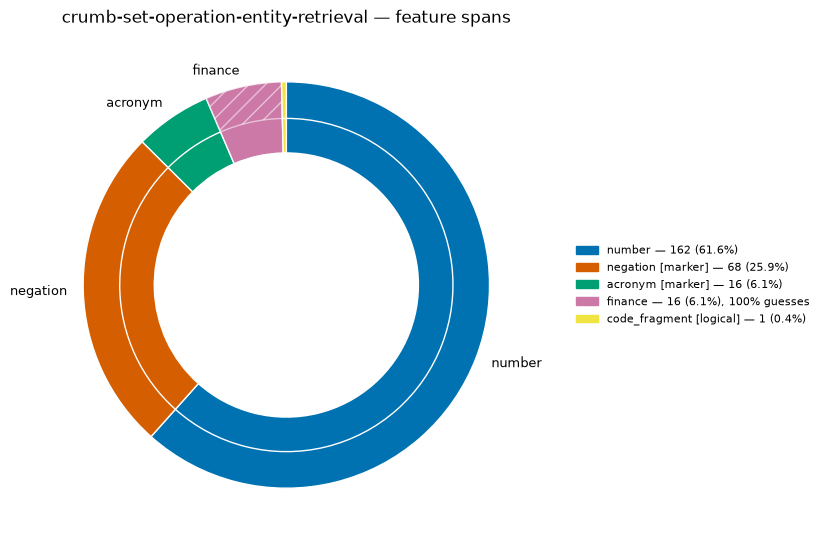

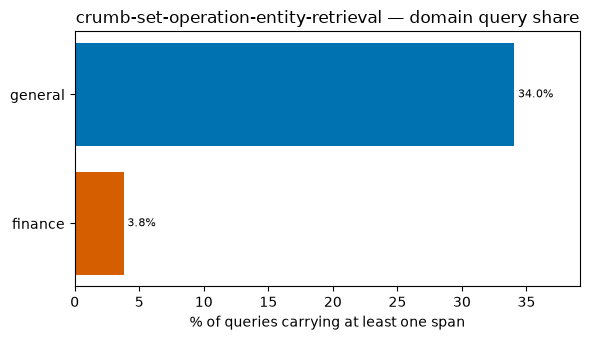

In [32]:
audit.show("crumb-set-operation-entity-retrieval")

**Verdict (draft): KEEP** — dominates 7 cells — mid-length single-span strata across all four axes, 91% certified.

_Edit this cell to record the final decision._

## crumb-stack-exchange

grounding=query_qrels  source=huggingface  availability=open  queries=107
identifiers: 1,276 spans, 82% certified — top: tech (600), number (261), datetime (117)
dominates 1 coverage cells:
  identifier spans per query: 0 x 3+ spans


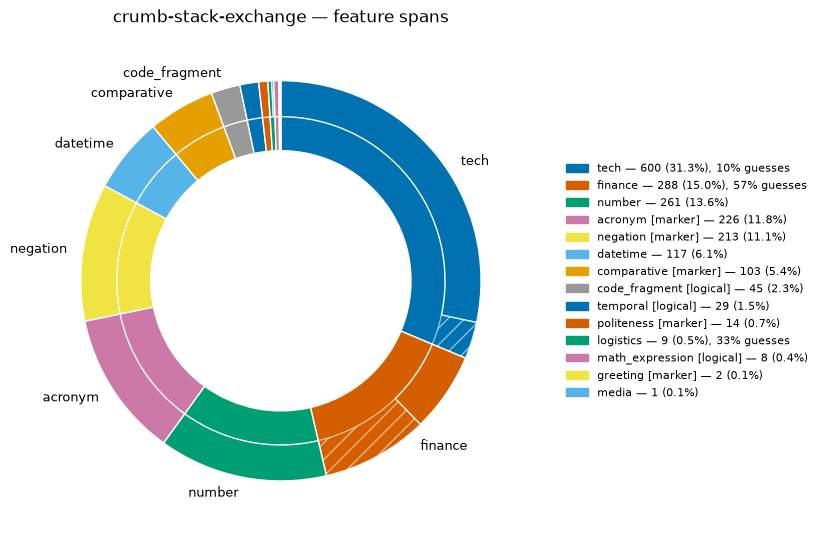

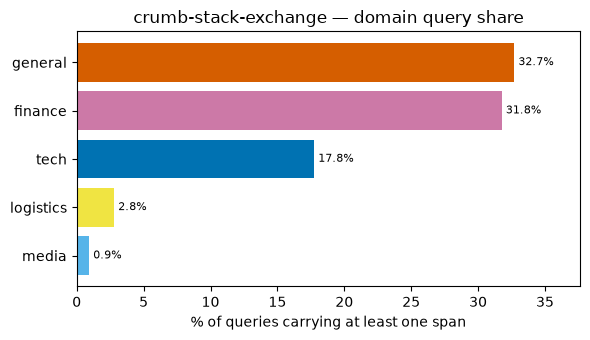

In [33]:
audit.show("crumb-stack-exchange")

**Verdict (draft): LEAN KEEP** — dominates 1 cell, but an interesting one: 0 identifiers × 3+ marker/logical spans — evidence-rich yet identifier-free queries; also the only tech-dominant donut (600 tech spans).

_Edit this cell to record the final decision._

## crumb-theorem-retrieval

grounding=query_qrels  source=huggingface  availability=open  queries=69
identifiers: 249 spans, 100% certified — top: number (191), tech (50), finance (5)
dominates 5 coverage cells:
  length_words: 20-59 x 1 span
  identifier spans per query: 2 x 1 span
  identifier spans per query: 1 x 2 spans
  identifier spans per query: 2 x 2 spans
  natural_language_share: 0.4+ sentence x 3+ spans


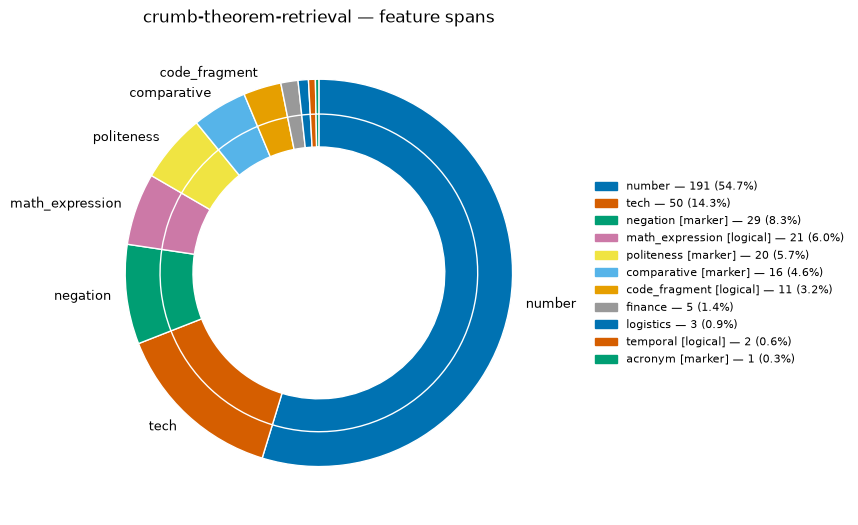

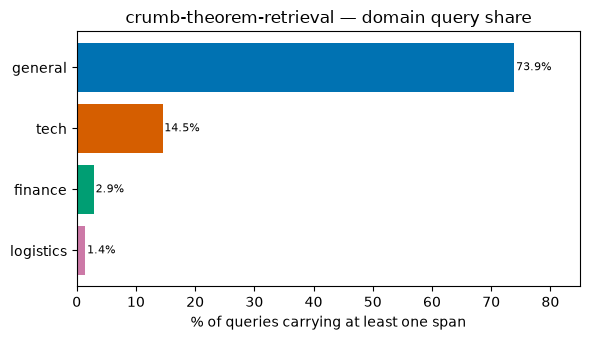

In [34]:
audit.show("crumb-theorem-retrieval")

**Verdict (draft): KEEP** — dominates 5 cells from 69 queries — 1-2 identifier × sentence-shaped strata, 100% certified.

_Edit this cell to record the final decision._

## crumb-tip-of-the-tongue

grounding=query_qrels  source=huggingface  availability=open  queries=135
identifiers: 288 spans, 72% certified — top: number (199), finance (85), tech (4)
dominates 2 coverage cells:
  identifier spans per query: 2 x 3+ spans
  natural_language_share: 0.4+ sentence x 2 spans


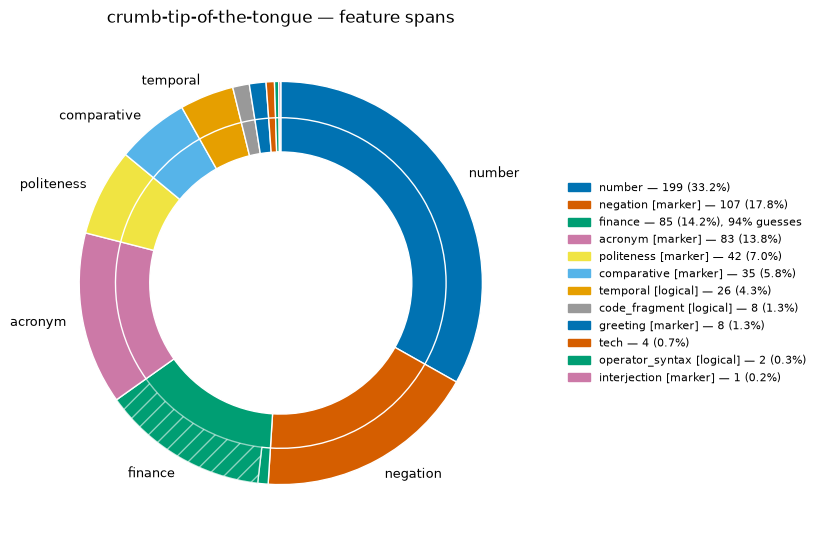

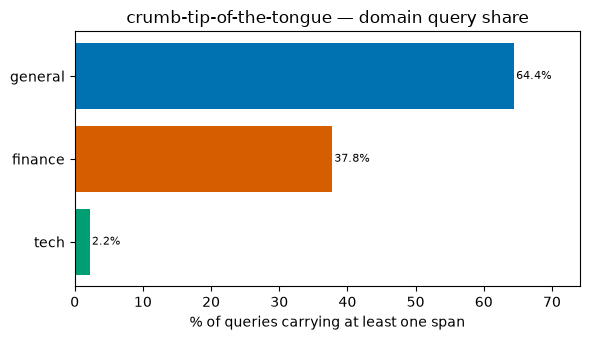

In [35]:
audit.show("crumb-tip-of-the-tongue")

**Verdict (draft): KEEP** — dominates 2 cells — sentence-shaped multi-span queries (0.4+ NL share × 2 spans, 2 ids × 3+ spans).

_Edit this cell to record the final decision._

## rarb-math

grounding=query_qrels  source=huggingface  availability=open  queries=6,319
identifiers: 43,950 spans, 90% certified — top: number (31907), finance (7745), tech (4241)
dominates 8 coverage cells:
  length_words: 20-59 x 2 spans
  length_words: 7-9 x 3+ spans
  length_words: 10-19 x 3+ spans
  identifier spans per query: 2 x 0 spans
  identifier spans per query: 3+ x 0 spans
  nesting_depth: 4-5 x 2 spans
  nesting_depth: 2-3 x 3+ spans
  nesting_depth: 4-5 x 3+ spans


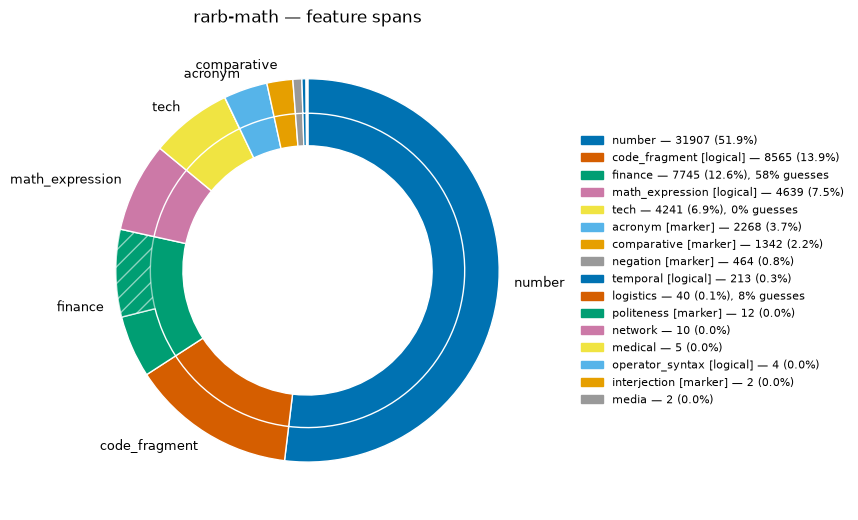

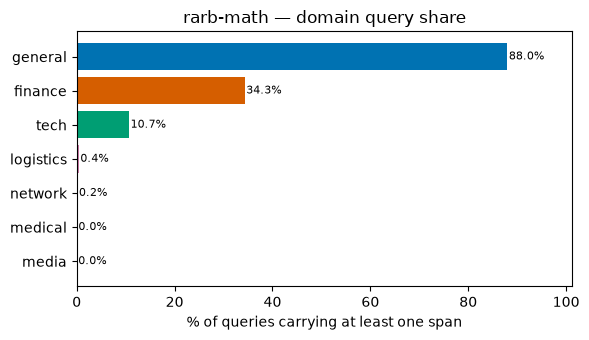

In [36]:
audit.show("rarb-math")

**Verdict (draft): KEEP** — dominates 8 cells — the mid-to-long math stratum owner (2-3+ ids, deep nesting), 90% certified at 44K spans.

_Edit this cell to record the final decision._

## rarb-code

grounding=query_qrels  source=huggingface  availability=open  queries=1,484
identifiers: 12,993 spans, 99% certified — top: number (9148), tech (3166), media (439)
dominates 2 coverage cells:
  natural_language_share: <0.1 telegram x 3+ spans
  natural_language_share: 0.1-0.25 x 3+ spans


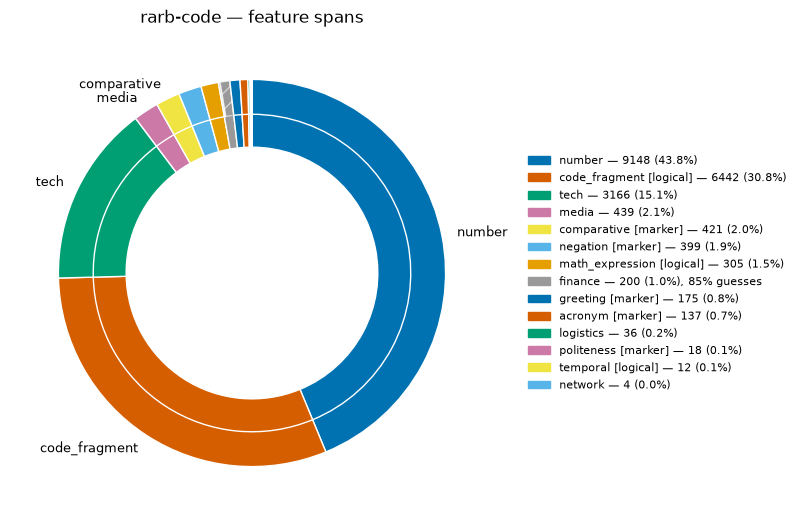

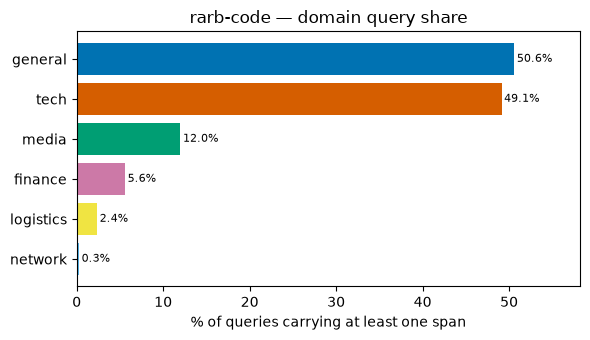

In [37]:
audit.show("rarb-code")

**Verdict (draft): KEEP** — dominates 2 cells — telegram-shaped 3+ span queries (NL share < 0.25), 99% certified.

_Edit this cell to record the final decision._

## limit

grounding=query_qrels  source=url  availability=open  queries=1,000
identifiers: 4 spans, 50% certified — top: finance (2), number (2)
dominates 5 coverage cells:
  length_words: 3-6 x 0 spans
  identifier spans per query: 0 x 0 spans
  nesting_depth: 0-1 x 0 spans
  natural_language_share: 0.1-0.25 x 0 spans
  natural_language_share: 0.25-0.4 x 0 spans


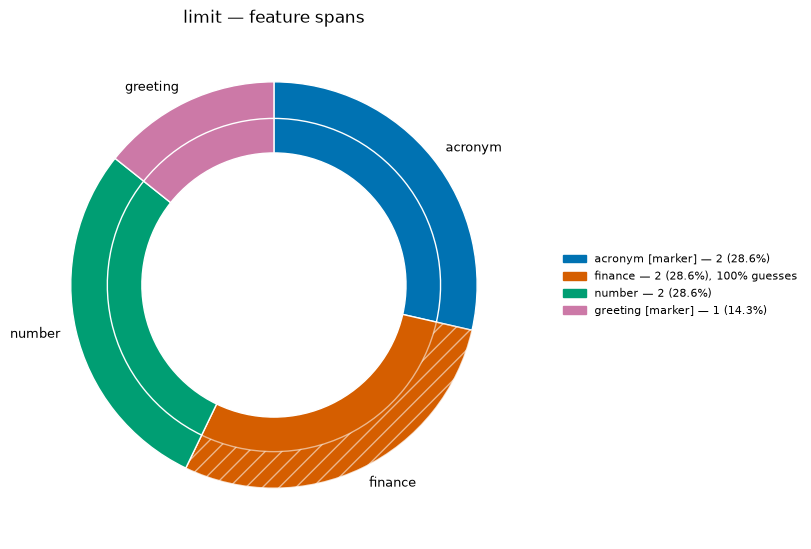

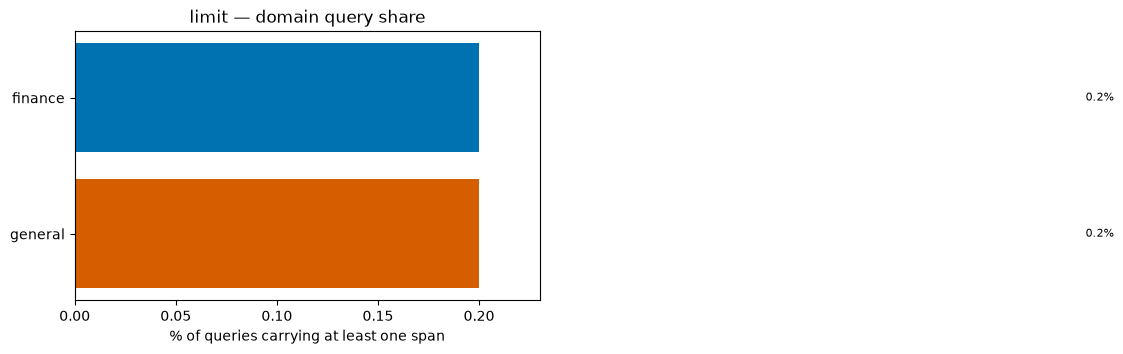

In [38]:
audit.show("limit")

**Verdict (draft): KEEP** — dominates 5 cells with only 4 identifier spans — owns the short plain-NL floor (3-6 words × 0 spans) across four axes.

_Edit this cell to record the final decision._